# Preprocesado y Modelado Base

## Objetivo
Entrenar y evaluar el primer modelo de clasificación binaria para predecir
si un juego será exitoso (`is_successful = 1`) a partir del dataset maestro.

## Estructura
- Bloque A — Carga e inspección del dataset maestro
- Bloque B — Preprocesado (outliers, scaling, train/test split)
- Bloque C — Modelo Base 1: XGBoost
- Bloque D — Modelo Base 2: Random Forest
- Bloque E — Comparativa y selección del mejor modelo


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

PROCESSED = Path('../data/processed/')

df = pd.read_parquet(PROCESSED / 'dataset_maestro.parquet')

# Separar features y target
DROP_COLS = ['appid', 'release_date', 'is_successful']
X = df.drop(columns=DROP_COLS)
y = df['is_successful']

# 2. Purgar TODO lo que no ocurrió matemáticamente en los primeros 30 días
LEAKAGE_COLS = [
    'owners_midpoint', 
    'peak_ccu', 
    'median_playtime_forever',
    'csv_review_count',
    # --- Añadimos las de Twitch porque no están filtradas a los primeros 30 días ---
    'twitch_peak_viewers', 
    'twitch_hours_watched', 
    'twitch_avg_viewers', 
    'twitch_months_in_top200'
]
X = X.drop(columns=LEAKAGE_COLS, errors='ignore')

# Identificar tipos de columnas
num_cols  = X.select_dtypes(include=[np.number]).columns.tolist()
bool_cols = X.select_dtypes(include=['bool']).columns.tolist()

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"\nColumnas numéricas:  {len(num_cols)}")
print(f"Columnas booleanas:  {len(bool_cols)}")
print(f"\nDistribución del target:")
print(y.value_counts())
print(f"Ratio desbalance: {y.value_counts()[0]/y.value_counts()[1]:.2f}:1")


Shape X: (11371, 60)
Shape y: (11371,)

Columnas numéricas:  60
Columnas booleanas:  0

Distribución del target:
is_successful
0    8072
1    3299
Name: count, dtype: int64
Ratio desbalance: 2.45:1


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# ── 1. Convertir booleanos a int ──────────────────────────────────
for col in bool_cols:
    X[col] = X[col].astype(int)

# ── 2. Tratar outliers extremos con log1p ─────────────────────────
# avg_early_playtime y avg_early_helpfulness tienen colas muy largas
outlier_cols = ['avg_early_playtime', 'avg_early_helpfulness']

for col in outlier_cols:
    if col in X.columns:
        X[col] = np.log1p(X[col])

print(" Log1p aplicado a:", outlier_cols)

# ── 3. Train/test split estratificado ─────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # mantener proporción 70%/30% en ambos splits
)

print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train positivos: {y_train.mean():.3f}  |  Test positivos: {y_test.mean():.3f}")

# ── 4. Escalar features numéricas (RobustScaler → resistente a outliers) ─
# Las columnas bool/dummy no se escalan
scale_cols = [c for c in num_cols if c not in 
              [col for col in X.columns if col.startswith('genre_') 
               or col.startswith('tag_') or col in bool_cols]]

scaler = RobustScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print(f"\n RobustScaler aplicado a {len(scale_cols)} columnas numéricas")
print(f"Columnas escaladas: {scale_cols}")


 Log1p aplicado a: ['avg_early_playtime', 'avg_early_helpfulness']

Train: (9096, 60)  |  Test: (2275, 60)
Train positivos: 0.290  |  Test positivos: 0.290

 RobustScaler aplicado a 17 columnas numéricas
Columnas escaladas: ['required_age', 'price_clean', 'is_free', 'is_software_tool', 'num_languages', 'num_categories', 'has_full_audio', 'early_review_count', 'early_positive_ratio', 'avg_review_len_chars', 'median_review_len_chars', 'bug_mention_ratio', 'avg_sentiment_score', 'std_sentiment_score', 'avg_early_helpfulness', 'avg_early_playtime', 'appeared_on_twitch_top200']


In [3]:
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# scale_pos_weight compensa el desbalance 70/30
ratio_desbalance = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = ratio_desbalance,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 42,
    n_jobs            = -1
)

xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=50)

y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBoost — Resultados ===")
print(classification_report(y_test, y_pred_xgb, 
                             target_names=['No exitoso', 'Exitoso']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")


[0]	validation_0-logloss:0.68761
[50]	validation_0-logloss:0.47270
[100]	validation_0-logloss:0.45409


c:\Users\longm\Documents\VIU 2.0\Master Big Data\TFM\Python files\venv_tfm\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:25:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[150]	validation_0-logloss:0.44939
[200]	validation_0-logloss:0.44863
[250]	validation_0-logloss:0.44685
[299]	validation_0-logloss:0.44479

=== XGBoost — Resultados ===
              precision    recall  f1-score   support

  No exitoso       0.87      0.82      0.85      1615
     Exitoso       0.62      0.70      0.66       660

    accuracy                           0.79      2275
   macro avg       0.74      0.76      0.75      2275
weighted avg       0.80      0.79      0.79      2275

ROC-AUC: 0.8520


In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = None,
    class_weight = 'balanced',   # equivalente a scale_pos_weight en XGB
    random_state = 42,
    n_jobs       = -1
)

rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest — Resultados ===")
print(classification_report(y_test, y_pred_rf, 
                             target_names=['No exitoso', 'Exitoso']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")


=== Random Forest — Resultados ===
              precision    recall  f1-score   support

  No exitoso       0.82      0.94      0.87      1615
     Exitoso       0.76      0.49      0.59       660

    accuracy                           0.81      2275
   macro avg       0.79      0.71      0.73      2275
weighted avg       0.80      0.81      0.79      2275

ROC-AUC: 0.8499


In [5]:
# ── Tabla comparativa ─────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

resultados = pd.DataFrame({
    'Modelo': ['XGBoost', 'Random Forest'],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_proba_xgb), 4),
        round(roc_auc_score(y_test, y_proba_rf), 4)
    ],
    'F1 (exitoso)': [
        round(f1_score(y_test, y_pred_xgb), 4),
        round(f1_score(y_test, y_pred_rf), 4)
    ],
    'Precision (exitoso)': [
        round(precision_score(y_test, y_pred_xgb), 4),
        round(precision_score(y_test, y_pred_rf), 4)
    ],
    'Recall (exitoso)': [
        round(recall_score(y_test, y_pred_xgb), 4),
        round(recall_score(y_test, y_pred_rf), 4)
    ]
})

print(resultados.to_string(index=False))

# ── Top 20 features más importantes (XGBoost) ────────────────────
feat_imp = pd.Series(xgb.feature_importances_, 
                     index=X_train.columns).sort_values(ascending=False)

print(f"\n=== Top 20 Features (XGBoost) ===")
print(feat_imp.head(20).to_string())


       Modelo  ROC-AUC  F1 (exitoso)  Precision (exitoso)  Recall (exitoso)
      XGBoost   0.8520        0.6582               0.6175            0.7045
Random Forest   0.8499        0.5923               0.7571            0.4864

=== Top 20 Features (XGBoost) ===
early_positive_ratio           0.083543
early_review_count             0.047184
is_free                        0.030603
genre_sports                   0.025348
avg_early_helpfulness          0.023605
bug_mention_ratio              0.023263
avg_sentiment_score            0.022343
price_clean                    0.021805
tag_anime                      0.021774
genre_indie                    0.021759
tag_story_rich                 0.021052
avg_review_len_chars           0.020816
tag_fantasy                    0.020778
median_review_len_chars        0.020452
tag_first_person               0.020098
genre_early_access             0.020005
avg_early_playtime             0.019945
tag_2d                         0.019816
std_sentiment_sco

---

##  Resumen de Modelado Base

Hasta este punto, hemos establecido la línea base (*baseline*) de nuestro modelo predictivo. Durante este proceso, se han tomado decisiones críticas de diseño para garantizar la robustez académica del modelo:

1. **Purga de Variables Contaminadas:**
   Se han eliminado explícitamente variables acumulativas históricas que el modelo no conocería en el día 30 (ej. `owners_midpoint`, `median_playtime_forever` y las métricas agregadas históricas de Twitch) para evitar Data Leakage.

2. **Resultados de la Línea Base:**
   Con configuración, nuestro modelo base de **XGBoost** consigue un **ROC-AUC de 0.8520** y un **Recall del 70.4%**. El Random Forest ofrece mayor precisión (75.7%) pero penaliza fuertemente el Recall (48.6%).

###  Siguientes Pasos (Bloque F - Optimización y Evaluación Final)

Dado que XGBoost ha demostrado el mejor equilibrio global (F1-Score: 0.658), será nuestro algoritmo principal. Procederemos con:

1. **Hyperparameter Tuning:** Utilizaremos `RandomizedSearchCV` para buscar la mejor combinación de hiperparámetros (profundidad del árbol, tasa de aprendizaje, regularización), validando con Cross-Validation de 5 particiones.
2. **Evaluación Visual:** Construiremos las gráficas estándar de la industria (Matriz de Confusión, Curva ROC, Curva Precision-Recall) sobre el modelo optimizado.
3. **Análisis de Importancia:** Visualizaremos los drivers principales que impulsan el éxito temprano de un videojuego según nuestro algoritmo.

---


# Optimización de hiperparametros

In [6]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
import time

print("Iniciando búsqueda de hiperparámetros con RandomizedSearchCV...")
start_time = time.time()

# 1. Definir el espacio de búsqueda de XGBoost
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.5, 1, 2],           # Regularización (reducción de overfitting)
    'min_child_weight': [1, 3, 5, 7]        # Regularización adicional
}

# 2. Instanciar el modelo base (mantenemos el peso para el desbalance)
ratio_desbalance = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_base = XGBClassifier(
    scale_pos_weight=ratio_desbalance,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# 3. Configurar la validación cruzada estratificada (5 folds)
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Configurar el RandomizedSearchCV
# n_iter=30: Probará 30 combinaciones aleatorias de las miles posibles
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,                     
    scoring='roc_auc',             # Optimizamos ROC-AUC
    cv=cv_strat,
    verbose=1,
    random_state=42,
    n_jobs=-1                      # Usar todos los cores disponibles
)

# 5. Entrenar (esto puede tardar unos minutos)
random_search.fit(X_train, y_train)

# 6. Resultados
end_time = time.time()
print(f"\n✅ Búsqueda completada en {(end_time - start_time)/60:.1f} minutos.")
print("\n🏆 Mejores hiperparámetros encontrados:")
for param, value in random_search.best_params_.items():
    print(f"  - {param}: {value}")

print(f"\nMejor ROC-AUC en Cross-Validation: {random_search.best_score_:.4f}")

# Guardamos el mejor modelo para las visualizaciones
best_xgb = random_search.best_estimator_


Iniciando búsqueda de hiperparámetros con RandomizedSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Búsqueda completada en 0.2 minutos.

🏆 Mejores hiperparámetros encontrados:
  - subsample: 1.0
  - n_estimators: 200
  - min_child_weight: 1
  - max_depth: 5
  - learning_rate: 0.05
  - gamma: 0.5
  - colsample_bytree: 0.8

Mejor ROC-AUC en Cross-Validation: 0.8495


=== Resultados Finales en el Conjunto de Test ===
              precision    recall  f1-score   support

  No exitoso       0.89      0.78      0.83      1615
     Exitoso       0.59      0.75      0.66       660

    accuracy                           0.77      2275
   macro avg       0.74      0.77      0.75      2275
weighted avg       0.80      0.77      0.78      2275



C:\Users\longm\AppData\Local\Temp\ipykernel_12052\597282113.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=df_imp, palette='viridis', ax=ax4)



✅ Gráfico guardado exitosamente en: ..\data\processed\xgb_evaluation_dashboard.png


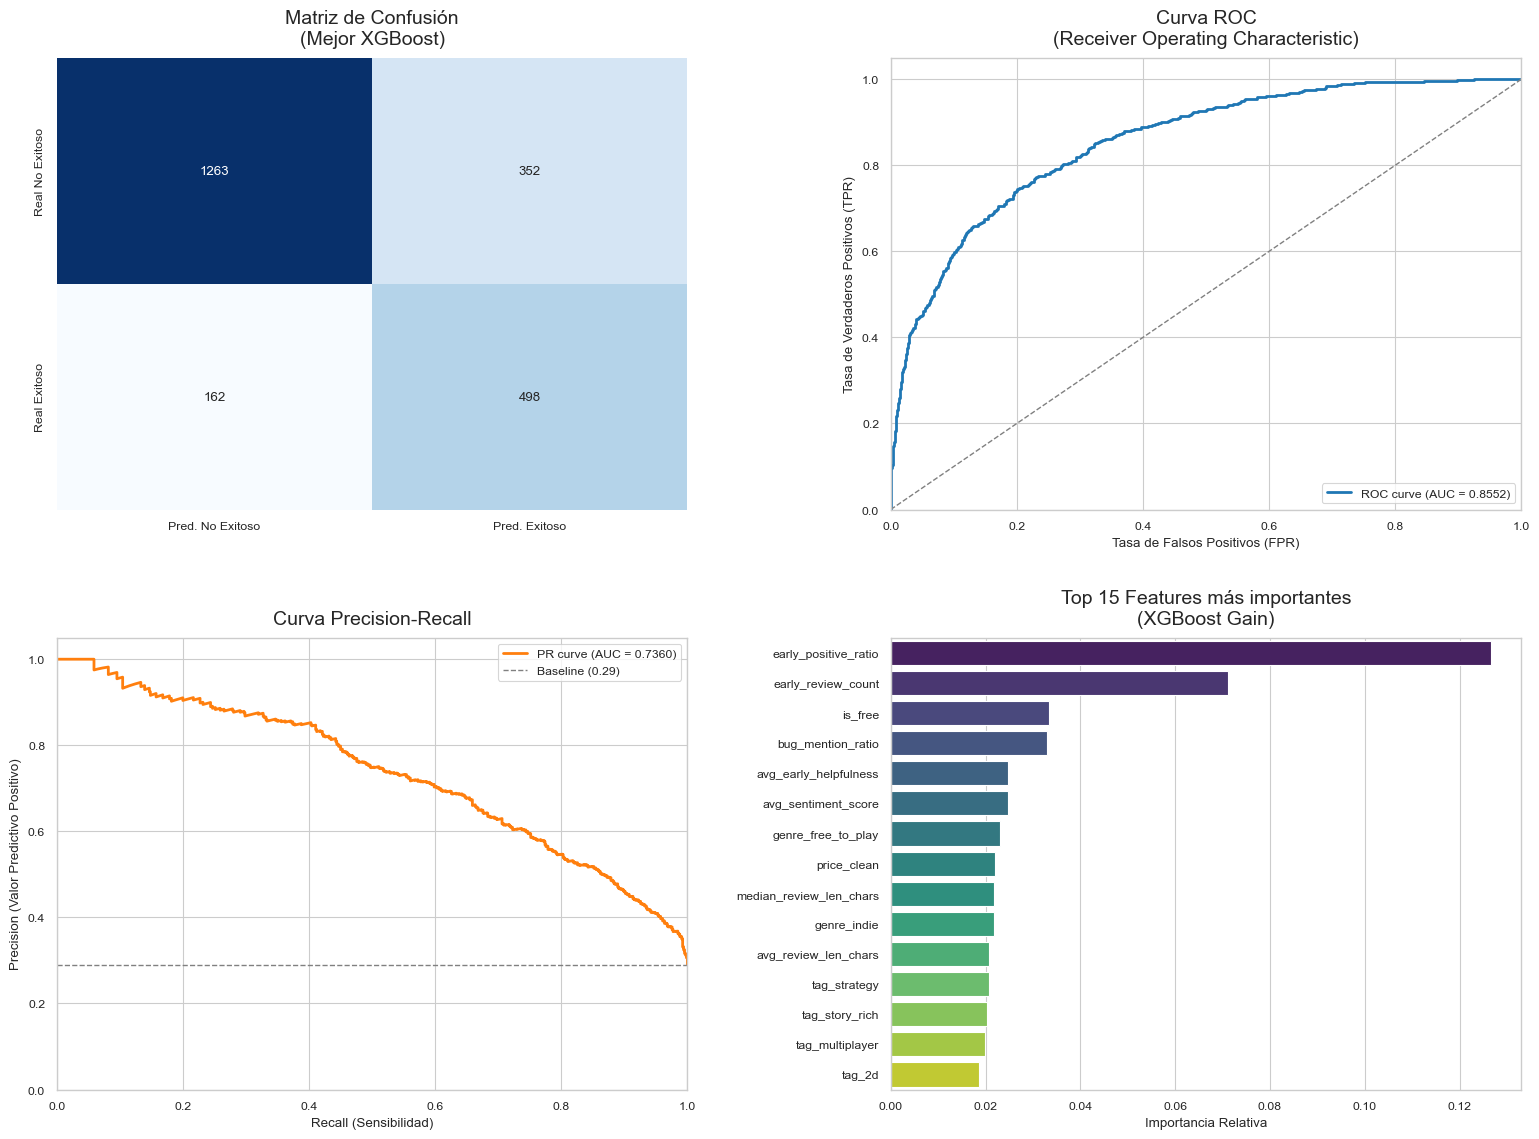

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_curve, precision_recall_curve, auc, 
                             confusion_matrix, classification_report)

# Predicciones con el MEJOR modelo
y_pred_best = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

# Métricas sobre test (para comparar con la línea base)
print("=== Resultados Finales en el Conjunto de Test ===")
print(classification_report(y_test, y_pred_best, target_names=['No exitoso', 'Exitoso']))

# Configuración de estilo global para las gráficas
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['figure.figsize'] = (16, 12)

fig = plt.figure()

# ---------------------------------------------------------
# 1. MATRIZ DE CONFUSIÓN
# ---------------------------------------------------------
ax1 = plt.subplot(2, 2, 1)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred. No Exitoso', 'Pred. Exitoso'],
            yticklabels=['Real No Exitoso', 'Real Exitoso'], ax=ax1)
ax1.set_title('Matriz de Confusión\n(Mejor XGBoost)', fontsize=14, pad=10)

# ---------------------------------------------------------
# 2. CURVA ROC
# ---------------------------------------------------------
ax2 = plt.subplot(2, 2, 2)
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba_best)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax2.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax2.set_title('Curva ROC\n(Receiver Operating Characteristic)', fontsize=14, pad=10)
ax2.legend(loc="lower right")

# ---------------------------------------------------------
# 3. CURVA PRECISION-RECALL (Muy útil en desbalance)
# ---------------------------------------------------------
ax3 = plt.subplot(2, 2, 3)
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba_best)
pr_auc = auc(recall, precision)

# Baseline (Proporción de positivos en test)
baseline = sum(y_test) / len(y_test)

ax3.plot(recall, precision, color='#ff7f0e', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
ax3.plot([0, 1], [baseline, baseline], color='gray', lw=1, linestyle='--', 
         label=f'Baseline ({baseline:.2f})')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('Recall (Sensibilidad)')
ax3.set_ylabel('Precision (Valor Predictivo Positivo)')
ax3.set_title('Curva Precision-Recall', fontsize=14, pad=10)
ax3.legend(loc="upper right")

# ---------------------------------------------------------
# 4. TOP 15 FEATURE IMPORTANCE
# ---------------------------------------------------------
ax4 = plt.subplot(2, 2, 4)
importances = best_xgb.feature_importances_
# Crear un dataframe temporal para ordenar mejor
df_imp = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
df_imp = df_imp.sort_values('importance', ascending=False).head(15)

sns.barplot(x='importance', y='feature', data=df_imp, palette='viridis', ax=ax4)
ax4.set_title('Top 15 Features más importantes\n(XGBoost Gain)', fontsize=14, pad=10)
ax4.set_xlabel('Importancia Relativa')
ax4.set_ylabel('')

# Ajustar espaciado
plt.tight_layout(pad=3.0)

# Guardar la figura en alta calidad para el TFM
fig_path = PROCESSED / 'xgb_evaluation_dashboard.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n Gráfico guardado exitosamente en: {fig_path}")

plt.show()


---

##  Análisis de Resultados del Modelo Optimizado (Mejor XGBoost)

Tras la fase de optimización de hiperparámetros, el modelo XGBoost final fue evaluado sobre el conjunto de Test (datos nunca vistos por el modelo). Los resultados obtenidos demuestran una gran solidez predictiva y validan la estrategia de Feature Engineering implementada.

### 1. Métricas de Rendimiento Global
El modelo ha logrado aislar eficientemente la señal del ruido utilizando únicamente información de los primeros 30 días del lanzamiento:
*   **ROC-AUC (0.8552):** Indica una excelente capacidad de discriminación general. El modelo es capaz de distinguir correctamente entre un juego exitoso y uno fracasado en un 85.5% de los casos.
*   **PR-AUC (0.7360):** En un contexto de datos desbalanceados (donde la probabilidad base de éxito es de apenas el 29%, línea punteada gris), alcanzar un área de 0.736 en la curva Precision-Recall significa que el modelo supera ampliamente la estimación aleatoria, ofreciendo un alto grado de fiabilidad.

### 2. Matriz de Confusión y Visión de Negocio
Analizando el *classification report* para la clase "Exitoso":
*   **Recall (75%):** De los 660 juegos que realmente alcanzaron el éxito, el modelo logró identificar correctamente a 498. 
*   **Precision (59%):** Cuando el modelo alerta de que un juego será exitoso, acierta en cerca del 60% de las ocasiones.

**Impacto en la Industria:** Desde el punto de vista de un *Publisher* (editor de videojuegos), este equilibrio es muy favorable. Perderse un título potencialmente muy rentable (falso negativo) tiene un coste de oportunidad enorme. Por el contrario, asignar presupuesto de marketing a un juego prometedor que finalmente no triunfa (falso positivo), aunque tiene coste, es un riesgo inherente y aceptado en la industria del entretenimiento. El modelo minimiza los falsos negativos, alineándose con las necesidades del sector.

### 3. Explicabilidad del Modelo (Feature Importance)
El análisis de las 15 variables más importantes (basado en la ganancia en los árboles de XGBoost) cuenta una historia muy coherente sobre el ciclo de vida de un videojuego en Steam:

1.  **La Recepción Temprana:** `early_positive_ratio` (ratio de reseñas positivas) y `early_review_count` (volumen de participación) son, con diferencia, los factores más determinantes. 
2.  **El Modelo de Monetización:** La variable `is_free` y el precio (`price_clean`) figuran en el top 10. El modelo ha detectado que los juegos *Free-to-Play* presentan patrones de adopción y éxito radicalmente distintos a los juegos *Premium*.
3.  **La Importancia de la Calidad Técnica (NLP):** Nuestra feature manual `bug_mention_ratio` ocupa el 4º lugar de importancia general. Esto demuestra empíricamente que un lanzamiento defectuoso o plagado de problemas técnicos ("bugs", "crashes") impacta negativamente.
4.  **Análisis de Sentimiento:** La variable `avg_sentiment_score` (calculada vía VADER) también aporta un valor predictivo significativo, demostrando que la polaridad emocional del texto contiene matices que el simple voto binario (Recomendado / No Recomendado) de Steam no llega a capturar.

---
